# Method 2: Hierarchical Classification - Binary + Severity Grading

This notebook implements a two-model hierarchical approach for DR classification on Dataset-02:

**Model 1 - Binary Classification:**
- **Benign** (Grade 0 / No DR)
- **Malignant** (Grades 1-4 / Any DR present)
- Groups all DR-positive grades into a single "malignant" class

**Model 2 - Severity Classification (among malignant cases only):**
- Trained only on DR-positive samples (Grades 1-4)
- 4-class severity grading: Mild NPDR, Moderate NPDR, Severe NPDR, PDR

**Experiment Tracking:** TensorBoard (launch with `tensorboard --logdir=runs`)

**Architecture:** ResNet-50 (ImageNet pretrained) for both models.

## 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torch.utils.tensorboard import SummaryWriter

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    balanced_accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
    torch.backends.cudnn.benchmark = True
    print('cuDNN benchmark mode: enabled')

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.0 GB
cuDNN benchmark mode: enabled


## 2. Configuration

In [2]:
CONFIG = {
    'data_dir': os.path.join('..', 'dataset', 'Dataset-02', 'dataset_split'),
    'cache_dir': os.path.join('..', 'dataset', 'Dataset-02', 'dataset_split_cache256'),
    'cache_size': 256,
    'img_size': 224,
    'batch_size': 64,
    'epochs_binary': 15,
    'epochs_severity': 15,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    # 0 = load in main process. Workers hang under Jupyter on Windows (spawn
    # can't re-import notebook-defined state). The 256px on-disk cache makes
    # single-process loading fast enough — the bottleneck was JPEG decode of
    # the ~950px originals, not GPU compute.
    'num_workers': 0,
    'use_amp': True,
    'seed': 42,
    'binary_model_path': 'models/best_method2_binary_resnet50.pth',
    'severity_model_path': 'models/best_method2_severity_resnet50.pth',
    'experiment_name': 'DR_Method2_Hierarchical',
}

BINARY_LABELS = {0: 'Benign', 1: 'Malignant'}
SEVERITY_LABELS = {0: 'Mild NPDR', 1: 'Moderate NPDR', 2: 'Severe NPDR', 3: 'PDR'}
DR_LABELS = {0: 'No DR', 1: 'Mild NPDR', 2: 'Moderate NPDR', 3: 'Severe NPDR', 4: 'PDR'}

AMP_ENABLED = CONFIG['use_amp'] and torch.cuda.is_available()

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG['seed'])

## 3. Load Data & Create Binary Labels

In [3]:
train_csv = os.path.join(CONFIG['data_dir'], 'train', 'train.csv')
val_csv = os.path.join(CONFIG['data_dir'], 'val', 'val.csv')
test_csv = os.path.join(CONFIG['data_dir'], 'test', 'test.csv')

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

# Create binary labels: 0=Benign (Grade 0), 1=Malignant (Grades 1-4)
for df in [train_df, val_df, test_df]:
    df['binary_label'] = (df['DR_ICDR'] > 0).astype(int)

print('=== Binary Label Distribution ===')
for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    benign = (df['binary_label'] == 0).sum()
    malignant = (df['binary_label'] == 1).sum()
    print(f'{name:>5}: Benign={benign:>6} ({benign/len(df)*100:.1f}%) | '
          f'Malignant={malignant:>4} ({malignant/len(df)*100:.1f}%)')

=== Binary Label Distribution ===
Train: Benign= 12151 (93.4%) | Malignant= 864 (6.6%)
  Val: Benign=  1544 (94.6%) | Malignant=  88 (5.4%)
 Test: Benign=  1488 (91.9%) | Malignant= 131 (8.1%)


In [4]:
# Create malignant-only subsets for severity model
# Remap DR_ICDR grades 1-4 to 0-3 for the severity classifier
train_mal = train_df[train_df['binary_label'] == 1].copy()
val_mal = val_df[val_df['binary_label'] == 1].copy()
test_mal = test_df[test_df['binary_label'] == 1].copy()

for df in [train_mal, val_mal, test_mal]:
    df['severity_label'] = df['DR_ICDR'] - 1  # Grade 1->0, 2->1, 3->2, 4->3

print('\n=== Severity Distribution (Malignant Cases Only) ===')
for df, name in [(train_mal, 'Train'), (val_mal, 'Val'), (test_mal, 'Test')]:
    print(f'\n{name} ({len(df)} samples):')
    for sev, sev_name in SEVERITY_LABELS.items():
        count = (df['severity_label'] == sev).sum()
        print(f'  {sev_name:>15}: {count:>4} ({count/len(df)*100:.1f}%)')


=== Severity Distribution (Malignant Cases Only) ===

Train (864 samples):
        Mild NPDR:  124 (14.4%)
    Moderate NPDR:  357 (41.3%)
      Severe NPDR:   66 (7.6%)
              PDR:  317 (36.7%)

Val (88 samples):
        Mild NPDR:   11 (12.5%)
    Moderate NPDR:   44 (50.0%)
      Severe NPDR:    6 (6.8%)
              PDR:   27 (30.7%)

Test (131 samples):
        Mild NPDR:   23 (17.6%)
    Moderate NPDR:   50 (38.2%)
      Severe NPDR:    6 (4.6%)
              PDR:   52 (39.7%)


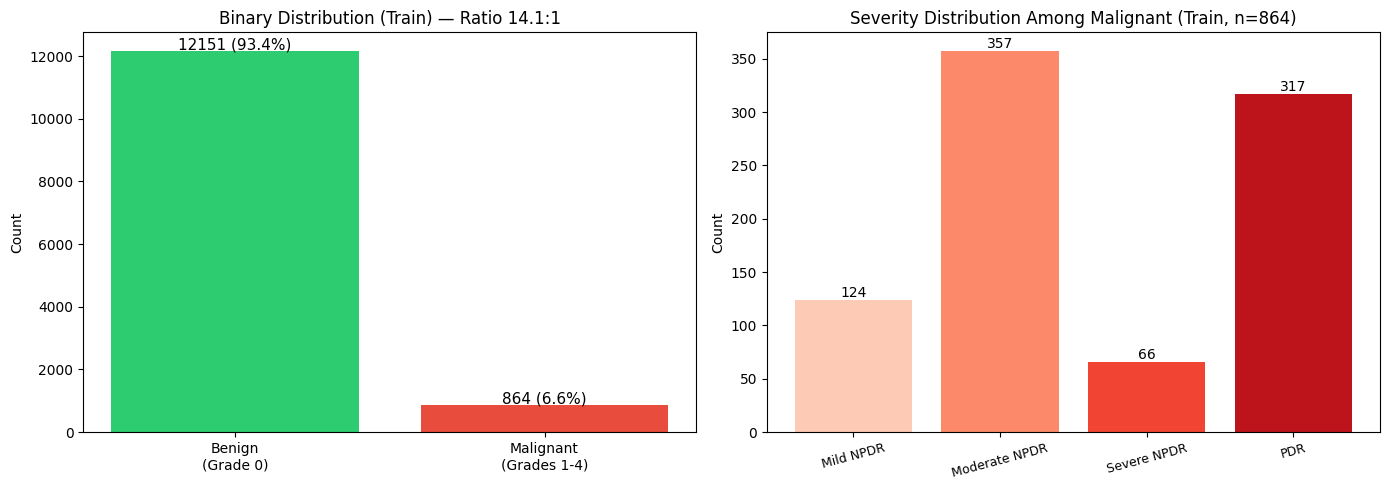

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary distribution
ax = axes[0]
benign = (train_df['binary_label'] == 0).sum()
malignant = (train_df['binary_label'] == 1).sum()
bars = ax.bar(['Benign\n(Grade 0)', 'Malignant\n(Grades 1-4)'],
              [benign, malignant], color=['#2ecc71', '#e74c3c'])
for bar, val in zip(bars, [benign, malignant]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val} ({val/len(train_df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Count')
ax.set_title(f'Binary Distribution (Train) — Ratio {benign/malignant:.1f}:1')

# Severity distribution among malignant
ax = axes[1]
sev_counts = train_mal['severity_label'].value_counts().sort_index()
bars = ax.bar(sev_counts.index, sev_counts.values, color=sns.color_palette('Reds', 4))
ax.set_xticks(range(4))
ax.set_xticklabels([SEVERITY_LABELS[i] for i in range(4)], rotation=15, fontsize=9)
ax.set_ylabel('Count')
ax.set_title(f'Severity Distribution Among Malignant (Train, n={len(train_mal)})')
for bar, count in zip(bars, sev_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{count}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/method2_label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Transforms

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('Transforms defined.')

Transforms defined.


## 5. Custom Dataset

In [7]:
class DRDataset(Dataset):
    def __init__(self, dataframe, img_dir, label_col, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['image_id']}.jpg")
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = int(row[self.label_col])
        return image, label

## 6. Helper Functions

In [8]:
def build_resnet50(num_classes, pretrained=True):
    model = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_classes)
    )
    return model


def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    total = 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=AMP_ENABLED):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.detach() * images.size(0)
        correct += outputs.detach().argmax(1).eq(labels).sum()
        total += labels.size(0)

    return running_loss.item() / total, correct.item() / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=AMP_ENABLED):
                outputs = model(images)
                loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            predicted = outputs.argmax(1)

            running_loss += loss.detach() * images.size(0)
            correct += predicted.eq(labels).sum()
            total += labels.size(0)

            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    epoch_loss = running_loss.item() / total
    epoch_acc = correct.item() / total
    f1_w = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1_m = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return epoch_loss, epoch_acc, f1_w, f1_m, all_preds, all_labels, all_probs


def plot_training_history(history, title, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history['train_loss'], label='Train', marker='o')
    axes[0].plot(history['val_loss'], label='Val', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history['train_acc'], label='Train', marker='o')
    axes[1].plot(history['val_acc'], label='Val', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(history['val_f1_weighted'], label='Weighted F1', marker='o')
    axes[2].plot(history['val_f1_macro'], label='Macro F1', marker='s')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_title('Validation F1 Scores')
    axes[2].legend()
    axes[2].grid(True)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

---
# PART A: Model 1 — Binary Classification (Benign vs Malignant)
---

## 7. Binary Model - Data Setup

In [36]:
# Pre-resize the dataset once into a small on-disk cache. Decoding the original
# ~950px fundus JPEGs is the training bottleneck: the cache is ~64x smaller and
# decodes an order of magnitude faster. Re-running this cell is a no-op if the
# cache already exists (built by Method 1).
from concurrent.futures import ThreadPoolExecutor

CACHE_SIZE = CONFIG['cache_size']


def _resize_one(job):
    src, dst = job
    if os.path.exists(dst):
        return 0
    with Image.open(src) as im:
        im.draft('RGB', (CACHE_SIZE, CACHE_SIZE))
        im = im.convert('RGB').resize((CACHE_SIZE, CACHE_SIZE), Image.BILINEAR)
        im.save(dst, 'JPEG', quality=95)
    return 1


def build_image_cache(split):
    src_dir = os.path.join(CONFIG['data_dir'], split, 'images')
    dst_dir = os.path.join(CONFIG['cache_dir'], split, 'images')
    os.makedirs(dst_dir, exist_ok=True)
    jobs = [(os.path.join(src_dir, n), os.path.join(dst_dir, n))
            for n in os.listdir(src_dir) if n.lower().endswith('.jpg')]
    with ThreadPoolExecutor(max_workers=8) as ex:
        written = sum(ex.map(_resize_one, jobs, chunksize=32))
    print(f'  {split:>5}: {len(jobs):>6} images ({written} newly written)')
    return dst_dir


print(f'Building {CACHE_SIZE}px image cache (skips files that already exist)...')
train_img_dir = build_image_cache('train')
val_img_dir = build_image_cache('val')
test_img_dir = build_image_cache('test')
print('Cache ready.')

Building 256px image cache (skips files that already exist)...
  train:  13015 images (0 newly written)
    val:   1632 images (0 newly written)
   test:   1619 images (0 newly written)
Cache ready.


In [37]:
# Binary datasets — point at the 256px cache, not the original images
bin_train_dataset = DRDataset(train_df, train_img_dir, 'binary_label', train_transforms)
bin_val_dataset = DRDataset(val_df, val_img_dir, 'binary_label', val_test_transforms)
bin_test_dataset = DRDataset(test_df, test_img_dir, 'binary_label', val_test_transforms)

# Weighted sampler for binary imbalance
bin_counts = train_df['binary_label'].value_counts().sort_index()
bin_class_weights = len(train_df) / (2 * bin_counts.values)
bin_sample_weights = torch.DoubleTensor(
    [bin_class_weights[label] for label in train_df['binary_label'].values]
)
bin_sampler = WeightedRandomSampler(bin_sample_weights, len(bin_sample_weights), replacement=True)

_loader_kwargs = dict(
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    persistent_workers=CONFIG['num_workers'] > 0,
    prefetch_factor=4 if CONFIG['num_workers'] > 0 else None,
)

bin_train_loader = DataLoader(bin_train_dataset, sampler=bin_sampler, **_loader_kwargs)
bin_val_loader = DataLoader(bin_val_dataset, shuffle=False, **_loader_kwargs)
bin_test_loader = DataLoader(bin_test_dataset, shuffle=False, **_loader_kwargs)

print(f'Binary class weights: {bin_class_weights}')
print(f'Train batches: {len(bin_train_loader)} | Val: {len(bin_val_loader)} | Test: {len(bin_test_loader)}')
print(f'Batch size: {CONFIG["batch_size"]} | Workers: {CONFIG["num_workers"]} | AMP: {AMP_ENABLED}')

Binary class weights: [0.53555263 7.5318287 ]
Train batches: 204 | Val: 26 | Test: 26
Batch size: 64 | Workers: 0 | AMP: True


## 8. Binary Model - Training

In [38]:
binary_model = build_resnet50(num_classes=2).to(device)

bin_weights_tensor = torch.FloatTensor(bin_class_weights).to(device)
bin_criterion = nn.CrossEntropyLoss(weight=bin_weights_tensor)
bin_optimizer = optim.Adam(binary_model.parameters(), lr=CONFIG['lr'],
                           weight_decay=CONFIG['weight_decay'])
bin_scheduler = optim.lr_scheduler.CosineAnnealingLR(bin_optimizer,
                                                      T_max=CONFIG['epochs_binary'],
                                                      eta_min=1e-6)

print(f'Binary Model - Parameters: {sum(p.numel() for p in binary_model.parameters()):,}')

Binary Model - Parameters: 23,512,130


In [39]:
# TensorBoard setup — shared writer for both models
writer = SummaryWriter(log_dir='runs/method2_hierarchical')
print('TensorBoard log dir: runs/method2_hierarchical')
print('Launch TensorBoard with: tensorboard --logdir=runs')

# Log hyperparameters as text
hparams_text = '\n'.join([f'{k}: {v}' for k, v in CONFIG.items()])
writer.add_text('Hyperparameters', hparams_text)

# Log binary model graph
dummy_input = torch.randn(1, 3, CONFIG['img_size'], CONFIG['img_size']).to(device)
writer.add_graph(binary_model, dummy_input)

# AMP GradScaler for mixed precision training
scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)

bin_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'val_f1_weighted': [], 'val_f1_macro': []
}

best_bin_f1 = 0.0

for epoch in range(CONFIG['epochs_binary']):
    train_loss, train_acc = train_one_epoch(
        binary_model, bin_train_loader, bin_criterion, bin_optimizer, device,
        scaler=scaler)
    val_loss, val_acc, val_f1_w, val_f1_m, _, _, _ = validate(
        binary_model, bin_val_loader, bin_criterion, device)

    bin_scheduler.step()

    bin_history['train_loss'].append(train_loss)
    bin_history['train_acc'].append(train_acc)
    bin_history['val_loss'].append(val_loss)
    bin_history['val_acc'].append(val_acc)
    bin_history['val_f1_weighted'].append(val_f1_w)
    bin_history['val_f1_macro'].append(val_f1_m)

    # Log to TensorBoard
    writer.add_scalars('Binary/Loss', {'train': train_loss, 'val': val_loss}, epoch)
    writer.add_scalars('Binary/Accuracy', {'train': train_acc, 'val': val_acc}, epoch)
    writer.add_scalar('Binary/F1_weighted', val_f1_w, epoch)
    writer.add_scalar('Binary/F1_macro', val_f1_m, epoch)
    writer.add_scalar('Binary/Learning_Rate', bin_optimizer.param_groups[0]['lr'], epoch)

    print(f'Epoch [{epoch+1}/{CONFIG["epochs_binary"]}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'F1-W: {val_f1_w:.4f} F1-M: {val_f1_m:.4f}')

    if val_f1_w > best_bin_f1:
        best_bin_f1 = val_f1_w
        torch.save(binary_model.state_dict(), CONFIG['binary_model_path'])
        print(f'  -> Best binary model saved (F1-W: {best_bin_f1:.4f})')

writer.flush()
print(f'\nBinary training complete. Best F1-weighted: {best_bin_f1:.4f}')

TensorBoard log dir: runs/method2_hierarchical
Launch TensorBoard with: tensorboard --logdir=runs


Epoch [1/15] Train Loss: 0.1592 Acc: 0.6840 | Val Loss: 0.3927 Acc: 0.7727 | F1-W: 0.8341 F1-M: 0.5890
  -> Best binary model saved (F1-W: 0.8341)


Epoch [2/15] Train Loss: 0.0994 Acc: 0.8078 | Val Loss: 0.3641 Acc: 0.7984 | F1-W: 0.8516 F1-M: 0.6056
  -> Best binary model saved (F1-W: 0.8516)


Epoch [3/15] Train Loss: 0.0688 Acc: 0.8737 | Val Loss: 0.3975 Acc: 0.7770 | F1-W: 0.8371 F1-M: 0.5925


Epoch [4/15] Train Loss: 0.0630 Acc: 0.8920 | Val Loss: 0.2031 Acc: 0.9283 | F1-W: 0.9399 F1-M: 0.7662
  -> Best binary model saved (F1-W: 0.9399)


...

Epoch [11/15] Train Loss: 0.0118 Acc: 0.9809 | Val Loss: 0.2959 Acc: 0.9632 | F1-W: 0.9656 F1-M: 0.8431
  -> Best binary model saved (F1-W: 0.9656)


Epoch [12/15] Train Loss: 0.0098 Acc: 0.9836 | Val Loss: 0.3203 Acc: 0.9651 | F1-W: 0.9667 F1-M: 0.8446
  -> Best binary model saved (F1-W: 0.9667)


Epoch [13/15] Train Loss: 0.0090 Acc: 0.9870 | Val Loss: 0.3015 Acc: 0.9688 | F1-W: 0.9700 F1-M: 0.8596
  -> Best binary model saved (F1-W: 0.9700)


Epoch [14/15] Train Loss: 0.0092 Acc: 0.9870 | Val Loss: 0.3312 Acc: 0.9724 | F1-W: 0.9729 F1-M: 0.8697
  -> Best binary model saved (F1-W: 0.9729)


Epoch [15/15] Train Loss: 0.0083 Acc: 0.9864 | Val Loss: 0.3386 Acc: 0.9724 | F1-W: 0.9726 F1-M: 0.8670

Binary training complete. Best F1-weighted: 0.9729


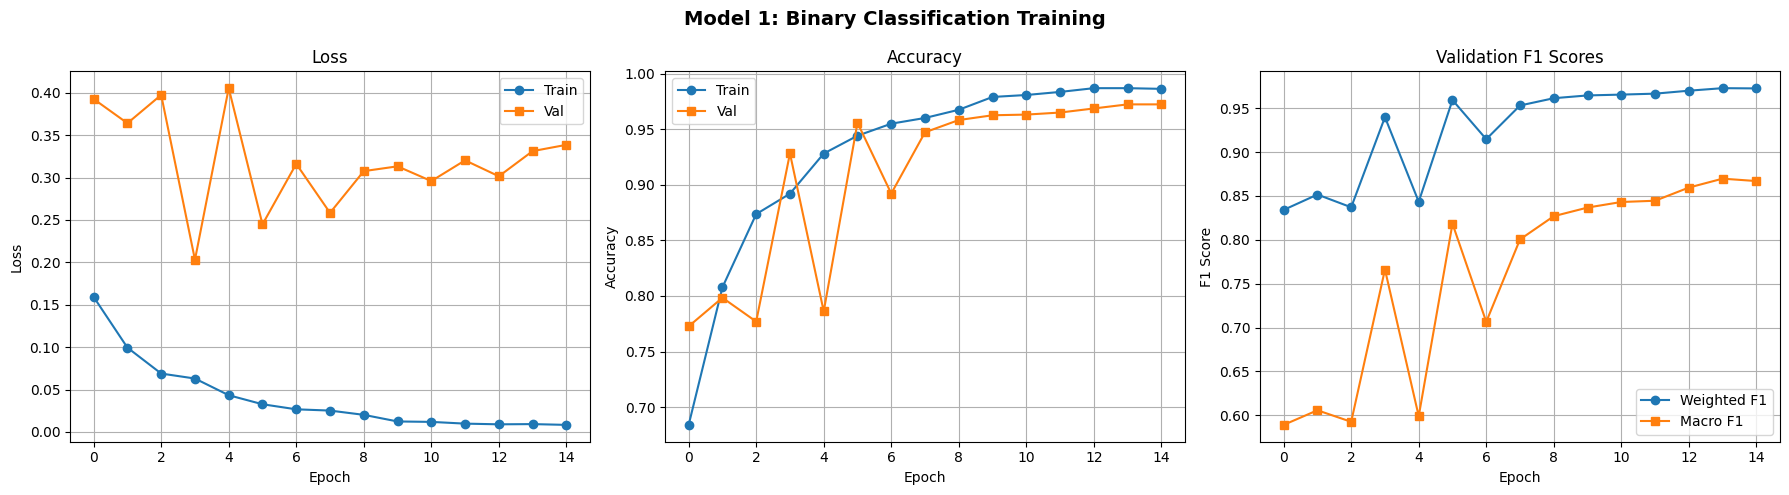

In [40]:
plot_training_history(bin_history, 'Model 1: Binary Classification Training',
                      'method2_binary_training_history.png')

## 9. Binary Model - Test Evaluation

In [41]:
binary_model.load_state_dict(torch.load(CONFIG['binary_model_path'], map_location=device))

bin_test_loss, bin_test_acc, bin_test_f1_w, bin_test_f1_m, \
    bin_test_preds, bin_test_labels, bin_test_probs = validate(
        binary_model, bin_test_loader, bin_criterion, device)

bin_test_bal_acc = balanced_accuracy_score(bin_test_labels, bin_test_preds)

print('=' * 60)
print('MODEL 1: BINARY CLASSIFICATION - TEST RESULTS')
print('=' * 60)
print(f'Accuracy:          {bin_test_acc:.4f}')
print(f'Balanced Accuracy: {bin_test_bal_acc:.4f}')
print(f'F1 (weighted):     {bin_test_f1_w:.4f}')
print(f'F1 (macro):        {bin_test_f1_m:.4f}')

# AUC-ROC
bin_probs_positive = bin_test_probs[:, 1]
try:
    auc_roc = roc_auc_score(bin_test_labels, bin_probs_positive)
    print(f'AUC-ROC:           {auc_roc:.4f}')
except ValueError:
    auc_roc = None
    print('AUC-ROC: Could not compute (single class in test set)')

print('\n=== Classification Report ===')
print(classification_report(bin_test_labels, bin_test_preds,
                            target_names=['Benign', 'Malignant'], zero_division=0))

Validating:   0%|          | 0/26 [00:00<?, ?it/s]

MODEL 1: BINARY CLASSIFICATION - TEST RESULTS
Accuracy:          0.9623
Balanced Accuracy: 0.8577
F1 (weighted):     0.9617
F1 (macro):        0.8692
AUC-ROC:           0.9515

=== Classification Report ===
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      1488
   Malignant       0.79      0.73      0.76       131

    accuracy                           0.96      1619
   macro avg       0.88      0.86      0.87      1619
weighted avg       0.96      0.96      0.96      1619



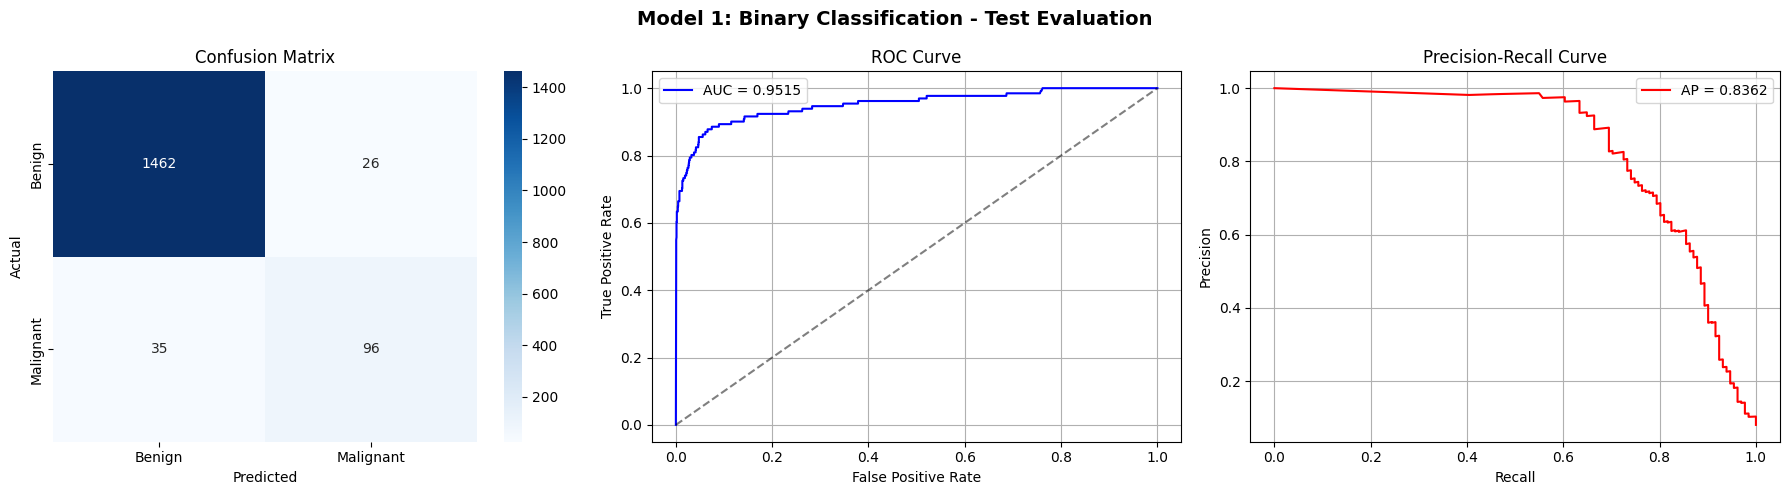

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(bin_test_labels, bin_test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
if auc_roc is not None:
    fpr, tpr, _ = roc_curve(bin_test_labels, bin_probs_positive)
    axes[1].plot(fpr, tpr, color='blue', label=f'AUC = {auc_roc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(True)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(bin_test_labels, bin_probs_positive)
ap = average_precision_score(bin_test_labels, bin_probs_positive)
axes[2].plot(recall, precision, color='red', label=f'AP = {ap:.4f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Model 1: Binary Classification - Test Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/method2_binary_evaluation.png', dpi=150, bbox_inches='tight')

# Log to TensorBoard
writer.add_figure('Binary_Test/Evaluation', fig, close=False)
writer.add_scalar('Binary_Test/accuracy', bin_test_acc)
writer.add_scalar('Binary_Test/balanced_accuracy', bin_test_bal_acc)
writer.add_scalar('Binary_Test/f1_weighted', bin_test_f1_w)
writer.add_scalar('Binary_Test/f1_macro', bin_test_f1_m)
if auc_roc is not None:
    writer.add_scalar('Binary_Test/auc_roc', auc_roc)
    writer.add_pr_curve('Binary_Test/PR_Curve', 
                        np.array(bin_test_labels), np.array(bin_probs_positive))
writer.flush()

plt.show()

---
# PART B: Model 2 — Severity Classification (Malignant Cases Only)
---

## 10. Severity Model - Data Setup

In [27]:
sev_train_dataset = DRDataset(train_mal, train_img_dir, 'severity_label', train_transforms)
sev_val_dataset = DRDataset(val_mal, val_img_dir, 'severity_label', val_test_transforms)
sev_test_dataset = DRDataset(test_mal, test_img_dir, 'severity_label', val_test_transforms)

# Weighted sampler for severity classes
sev_counts = train_mal['severity_label'].value_counts().sort_index()
sev_class_weights = len(train_mal) / (4 * sev_counts.values)
sev_sample_weights = torch.DoubleTensor(
    [sev_class_weights[label] for label in train_mal['severity_label'].values]
)
sev_sampler = WeightedRandomSampler(sev_sample_weights, len(sev_sample_weights), replacement=True)

sev_train_loader = DataLoader(sev_train_dataset, sampler=sev_sampler, **_loader_kwargs)
sev_val_loader = DataLoader(sev_val_dataset, shuffle=False, **_loader_kwargs)
sev_test_loader = DataLoader(sev_test_dataset, shuffle=False, **_loader_kwargs)

print(f'Severity datasets: Train={len(sev_train_dataset)} | Val={len(sev_val_dataset)} | Test={len(sev_test_dataset)}')
print(f'Severity class weights: {sev_class_weights}')

Severity datasets: Train=864 | Val=88 | Test=131
Severity class weights: [1.74193548 0.60504202 3.27272727 0.68138801]


## 11. Severity Model - Training

In [31]:
severity_model = build_resnet50(num_classes=4).to(device)

sev_weights_tensor = torch.FloatTensor(sev_class_weights).to(device)
sev_criterion = nn.CrossEntropyLoss(weight=sev_weights_tensor)
sev_optimizer = optim.Adam(severity_model.parameters(), lr=CONFIG['lr'],
                           weight_decay=CONFIG['weight_decay'])
sev_scheduler = optim.lr_scheduler.CosineAnnealingLR(sev_optimizer,
                                                      T_max=CONFIG['epochs_severity'],
                                                      eta_min=1e-6)

print(f'Severity Model - Parameters: {sum(p.numel() for p in severity_model.parameters()):,}')

Severity Model - Parameters: 23,516,228


In [32]:
sev_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'val_f1_weighted': [], 'val_f1_macro': []
}

best_sev_f1 = 0.0

for epoch in range(CONFIG['epochs_severity']):
    train_loss, train_acc = train_one_epoch(
        severity_model, sev_train_loader, sev_criterion, sev_optimizer, device,
        scaler=scaler)
    val_loss, val_acc, val_f1_w, val_f1_m, _, _, _ = validate(
        severity_model, sev_val_loader, sev_criterion, device)

    sev_scheduler.step()

    sev_history['train_loss'].append(train_loss)
    sev_history['train_acc'].append(train_acc)
    sev_history['val_loss'].append(val_loss)
    sev_history['val_acc'].append(val_acc)
    sev_history['val_f1_weighted'].append(val_f1_w)
    sev_history['val_f1_macro'].append(val_f1_m)

    # Log to TensorBoard
    writer.add_scalars('Severity/Loss', {'train': train_loss, 'val': val_loss}, epoch)
    writer.add_scalars('Severity/Accuracy', {'train': train_acc, 'val': val_acc}, epoch)
    writer.add_scalar('Severity/F1_weighted', val_f1_w, epoch)
    writer.add_scalar('Severity/F1_macro', val_f1_m, epoch)
    writer.add_scalar('Severity/Learning_Rate', sev_optimizer.param_groups[0]['lr'], epoch)

    print(f'Epoch [{epoch+1}/{CONFIG["epochs_severity"]}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'F1-W: {val_f1_w:.4f} F1-M: {val_f1_m:.4f}')

    if val_f1_w > best_sev_f1:
        best_sev_f1 = val_f1_w
        torch.save(severity_model.state_dict(), CONFIG['severity_model_path'])
        print(f'  -> Best severity model saved (F1-W: {best_sev_f1:.4f})')

writer.flush()
print(f'\nSeverity training complete. Best F1-weighted: {best_sev_f1:.4f}')

Epoch [1/15] Train Loss: 0.9776 Acc: 0.4039 | Val Loss: 1.4372 Acc: 0.1818 | F1-W: 0.0592 F1-M: 0.1550
  -> Best severity model saved (F1-W: 0.0592)


Epoch [2/15] Train Loss: 0.6536 Acc: 0.5347 | Val Loss: 1.0919 Acc: 0.2841 | F1-W: 0.2185 F1-M: 0.2865
  -> Best severity model saved (F1-W: 0.2185)


Epoch [3/15] Train Loss: 0.5369 Acc: 0.5984 | Val Loss: 1.1143 Acc: 0.4545 | F1-W: 0.4365 F1-M: 0.4592
  -> Best severity model saved (F1-W: 0.4365)


Epoch [4/15] Train Loss: 0.3659 Acc: 0.7535 | Val Loss: 0.9435 Acc: 0.5000 | F1-W: 0.4830 F1-M: 0.5003
  -> Best severity model saved (F1-W: 0.4830)


Epoch [5/15] Train Loss: 0.3197 Acc: 0.7396 | Val Loss: 0.8049 Acc: 0.5568 | F1-W: 0.5648 F1-M: 0.5389
  -> Best severity model saved (F1-W: 0.5648)


...

Epoch [11/15] Train Loss: 0.1280 Acc: 0.8900 | Val Loss: 0.7762 Acc: 0.7045 | F1-W: 0.7135 F1-M: 0.6814
  -> Best severity model saved (F1-W: 0.7135)


Epoch [12/15] Train Loss: 0.1261 Acc: 0.9132 | Val Loss: 0.7556 Acc: 0.7614 | F1-W: 0.7643 F1-M: 0.7393
  -> Best severity model saved (F1-W: 0.7643)


Epoch [13/15] Train Loss: 0.1153 Acc: 0.9144 | Val Loss: 0.7626 Acc: 0.7386 | F1-W: 0.7457 F1-M: 0.7081


Epoch [14/15] Train Loss: 0.1194 Acc: 0.9144 | Val Loss: 0.7883 Acc: 0.7273 | F1-W: 0.7359 F1-M: 0.6989


Epoch [15/15] Train Loss: 0.1291 Acc: 0.9086 | Val Loss: 0.8096 Acc: 0.7386 | F1-W: 0.7480 F1-M: 0.7294

Severity training complete. Best F1-weighted: 0.7643


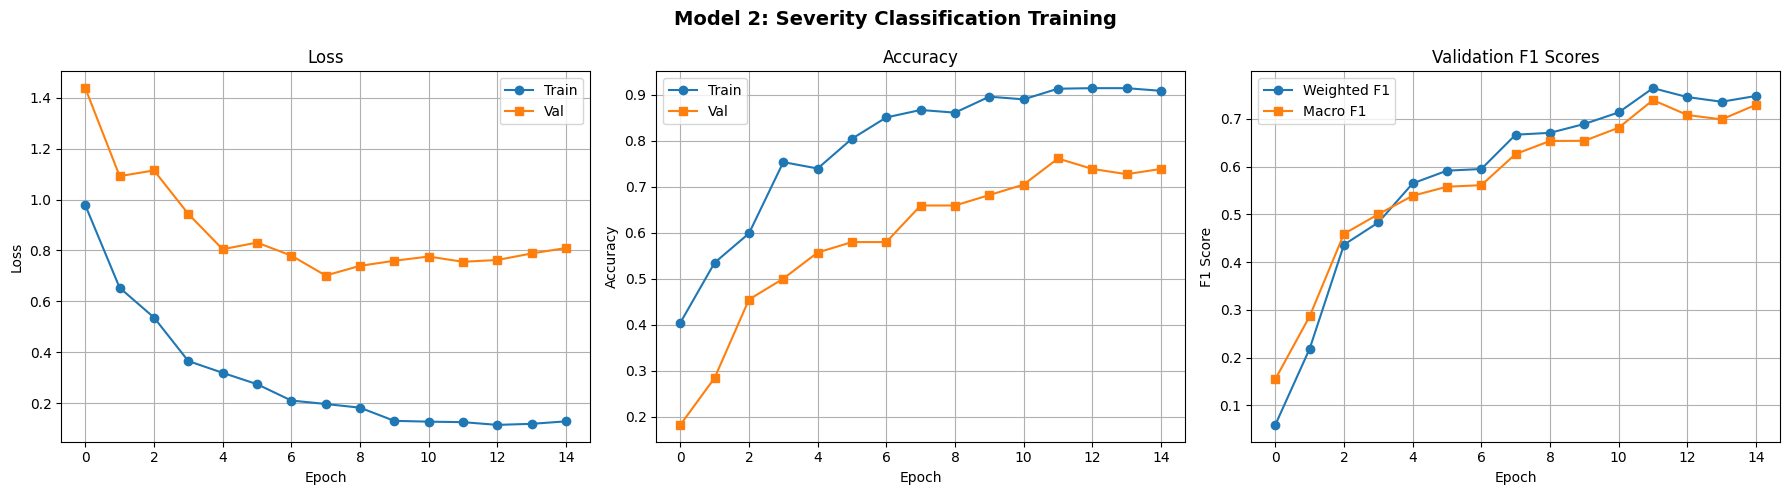

In [33]:
plot_training_history(sev_history, 'Model 2: Severity Classification Training',
                      'method2_severity_training_history.png')

## 12. Severity Model - Test Evaluation

In [34]:
severity_model.load_state_dict(torch.load(CONFIG['severity_model_path'], map_location=device))

sev_test_loss, sev_test_acc, sev_test_f1_w, sev_test_f1_m, \
    sev_test_preds, sev_test_labels, sev_test_probs = validate(
        severity_model, sev_test_loader, sev_criterion, device)

sev_test_bal_acc = balanced_accuracy_score(sev_test_labels, sev_test_preds)

print('=' * 60)
print('MODEL 2: SEVERITY CLASSIFICATION - TEST RESULTS')
print('=' * 60)
print(f'Test samples (malignant only): {len(sev_test_dataset)}')
print(f'Accuracy:          {sev_test_acc:.4f}')
print(f'Balanced Accuracy: {sev_test_bal_acc:.4f}')
print(f'F1 (weighted):     {sev_test_f1_w:.4f}')
print(f'F1 (macro):        {sev_test_f1_m:.4f}')

print('\n=== Classification Report ===')
print(classification_report(sev_test_labels, sev_test_preds,
                            target_names=[SEVERITY_LABELS[i] for i in range(4)],
                            zero_division=0))

Validating:   0%|          | 0/3 [00:00<?, ?it/s]

MODEL 2: SEVERITY CLASSIFICATION - TEST RESULTS
Test samples (malignant only): 131
Accuracy:          0.7252
Balanced Accuracy: 0.6536
F1 (weighted):     0.7352
F1 (macro):        0.6272

=== Classification Report ===
               precision    recall  f1-score   support

    Mild NPDR       0.57      0.57      0.57        23
Moderate NPDR       0.74      0.78      0.76        50
  Severe NPDR       0.27      0.50      0.35         6
          PDR       0.91      0.77      0.83        52

     accuracy                           0.73       131
    macro avg       0.62      0.65      0.63       131
 weighted avg       0.75      0.73      0.74       131



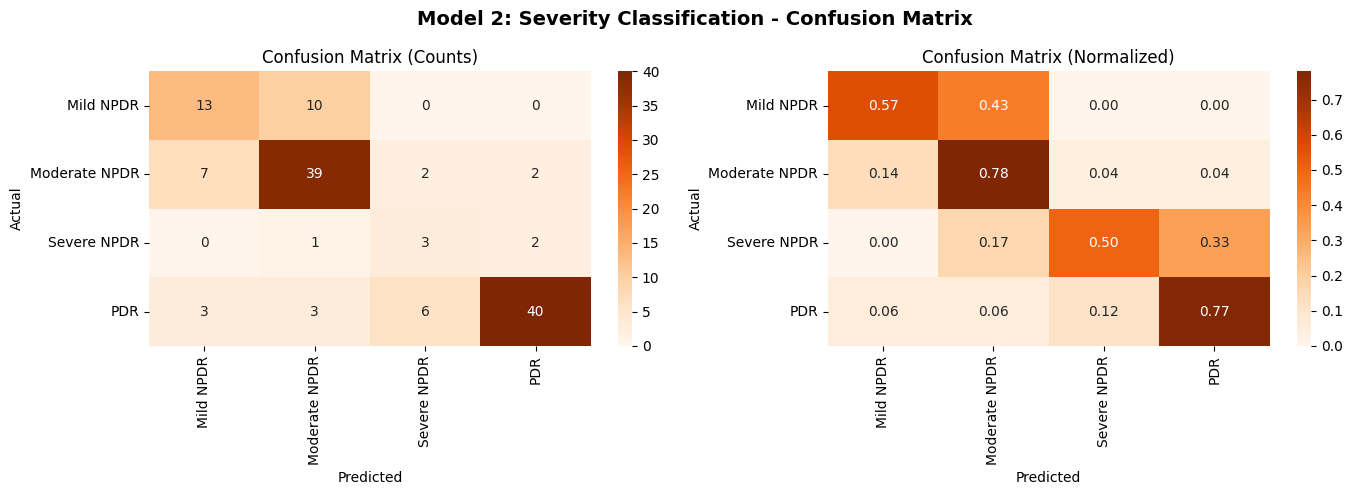

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (counts)
cm = confusion_matrix(sev_test_labels, sev_test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=[SEVERITY_LABELS[i] for i in range(4)],
            yticklabels=[SEVERITY_LABELS[i] for i in range(4)])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=[SEVERITY_LABELS[i] for i in range(4)],
            yticklabels=[SEVERITY_LABELS[i] for i in range(4)])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.suptitle('Model 2: Severity Classification - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/method2_severity_confusion_matrix.png', dpi=150, bbox_inches='tight')

# Log to TensorBoard
writer.add_figure('Severity_Test/Confusion_Matrix', fig, close=False)
writer.add_scalar('Severity_Test/accuracy', sev_test_acc)
writer.add_scalar('Severity_Test/balanced_accuracy', sev_test_bal_acc)
writer.add_scalar('Severity_Test/f1_weighted', sev_test_f1_w)
writer.add_scalar('Severity_Test/f1_macro', sev_test_f1_m)
writer.flush()

plt.show()

---
# PART C: Combined Hierarchical Pipeline Evaluation
---

## 13. End-to-End Pipeline on Test Set

Run the full two-stage pipeline:
1. Binary model predicts Benign vs Malignant
2. For predicted-Malignant cases, severity model predicts the grade
3. Map back to original 5-class DR_ICDR scale

In [43]:
binary_model.load_state_dict(torch.load(CONFIG['binary_model_path'], map_location=device))
severity_model.load_state_dict(torch.load(CONFIG['severity_model_path'], map_location=device))
binary_model.eval()
severity_model.eval()

full_test_dataset = DRDataset(test_df, test_img_dir, 'DR_ICDR', val_test_transforms)
full_test_loader = DataLoader(full_test_dataset, shuffle=False, **_loader_kwargs)

pipeline_preds = []
pipeline_labels = []

with torch.no_grad(), torch.amp.autocast('cuda', enabled=AMP_ENABLED):
    for images, labels in tqdm(full_test_loader, desc='Pipeline Inference'):
        images = images.to(device, non_blocking=True)

        # Stage 1: Binary classification on entire batch
        bin_outputs = binary_model(images)
        bin_preds = bin_outputs.argmax(1)

        # Start with all predictions as Grade 0 (benign)
        batch_preds = torch.zeros_like(bin_preds)

        # Stage 2: Run severity model only on predicted-malignant samples
        malignant_mask = bin_preds == 1
        if malignant_mask.any():
            mal_images = images[malignant_mask]
            sev_outputs = severity_model(mal_images)
            sev_preds = sev_outputs.argmax(1) + 1
            batch_preds[malignant_mask] = sev_preds

        pipeline_preds.extend(batch_preds.cpu().numpy())
        pipeline_labels.extend(labels.numpy())

print('Pipeline inference complete.')

Pipeline Inference: 100%|██████████| 26/26 [00:10<00:00,  2.38it/s]

Pipeline inference complete.


In [44]:
pipeline_acc = np.mean(np.array(pipeline_preds) == np.array(pipeline_labels))
pipeline_bal_acc = balanced_accuracy_score(pipeline_labels, pipeline_preds)
pipeline_f1_w = f1_score(pipeline_labels, pipeline_preds, average='weighted', zero_division=0)
pipeline_f1_m = f1_score(pipeline_labels, pipeline_preds, average='macro', zero_division=0)

print('=' * 60)
print('HIERARCHICAL PIPELINE - FULL TEST RESULTS (5-CLASS)')
print('=' * 60)
print(f'Accuracy:          {pipeline_acc:.4f}')
print(f'Balanced Accuracy: {pipeline_bal_acc:.4f}')
print(f'F1 (weighted):     {pipeline_f1_w:.4f}')
print(f'F1 (macro):        {pipeline_f1_m:.4f}')

target_names = [f'Grade {i} ({DR_LABELS[i]})' for i in range(5)]
print('\n=== Classification Report ===')
print(classification_report(pipeline_labels, pipeline_preds,
                            target_names=target_names, zero_division=0))

HIERARCHICAL PIPELINE - FULL TEST RESULTS (5-CLASS)
Accuracy:          0.9469
Balanced Accuracy: 0.5957
F1 (weighted):     0.9459
F1 (macro):        0.5785

=== Classification Report ===
                         precision    recall  f1-score   support

        Grade 0 (No DR)       0.98      0.98      0.98      1488
    Grade 1 (Mild NPDR)       0.41      0.30      0.35        23
Grade 2 (Moderate NPDR)       0.57      0.48      0.52        50
  Grade 3 (Severe NPDR)       0.23      0.50      0.32         6
          Grade 4 (PDR)       0.74      0.71      0.73        52

               accuracy                           0.95      1619
              macro avg       0.59      0.60      0.58      1619
           weighted avg       0.95      0.95      0.95      1619



TensorBoard writer closed. All metrics logged.


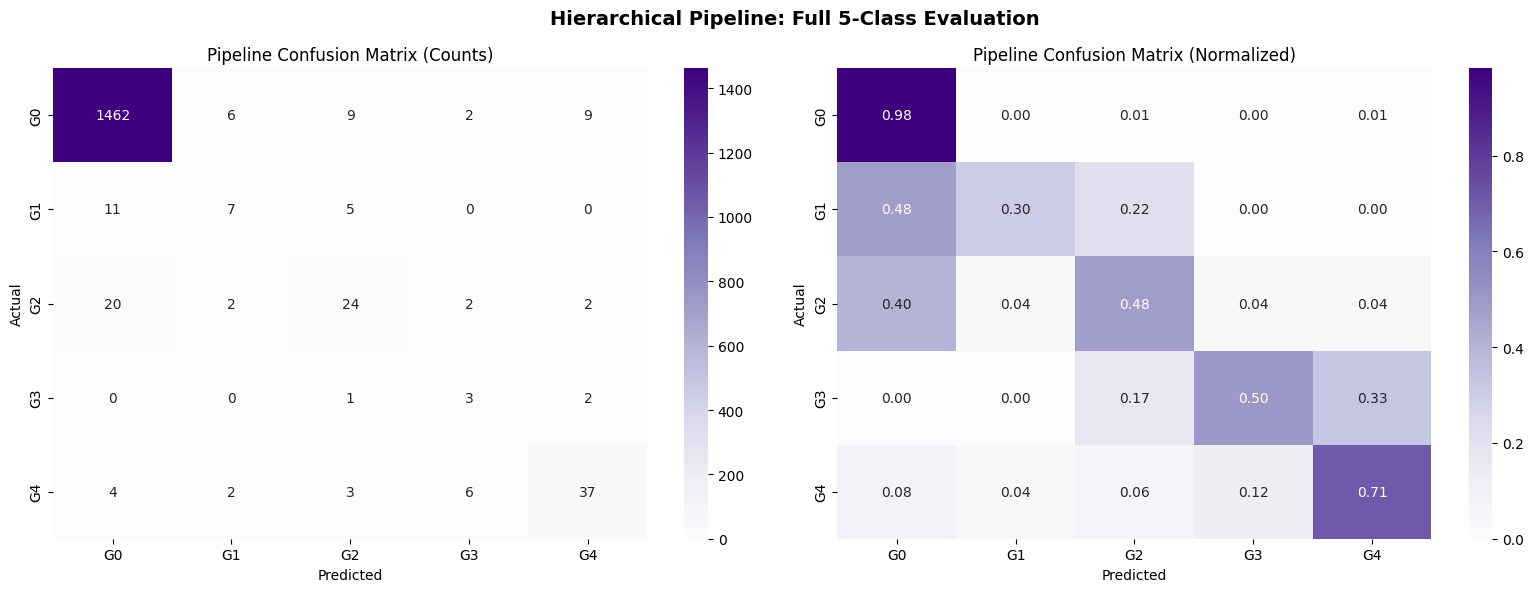

In [45]:
# Full pipeline confusion matrix
cm = confusion_matrix(pipeline_labels, pipeline_preds, labels=range(5))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=[f'G{i}' for i in range(5)],
            yticklabels=[f'G{i}' for i in range(5)])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Pipeline Confusion Matrix (Counts)')

cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples', ax=axes[1],
            xticklabels=[f'G{i}' for i in range(5)],
            yticklabels=[f'G{i}' for i in range(5)])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Pipeline Confusion Matrix (Normalized)')

plt.suptitle('Hierarchical Pipeline: Full 5-Class Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/method2_pipeline_confusion_matrix.png', dpi=150, bbox_inches='tight')

# Log pipeline results to TensorBoard
writer.add_figure('Pipeline/Confusion_Matrix', fig, close=False)
writer.add_hparams(
    {
        'lr': CONFIG['lr'],
        'batch_size': CONFIG['batch_size'],
        'epochs_binary': CONFIG['epochs_binary'],
        'epochs_severity': CONFIG['epochs_severity'],
        'img_size': CONFIG['img_size'],
    },
    {
        'hparam/pipeline_accuracy': pipeline_acc,
        'hparam/pipeline_balanced_accuracy': pipeline_bal_acc,
        'hparam/pipeline_f1_weighted': pipeline_f1_w,
        'hparam/pipeline_f1_macro': pipeline_f1_m,
        'hparam/binary_test_f1_weighted': bin_test_f1_w,
        'hparam/severity_test_f1_weighted': sev_test_f1_w,
    }
)

writer.close()
print('TensorBoard writer closed. All metrics logged.')
plt.show()

## 14. Summary

In [46]:
print('=' * 70)
print('METHOD 2 SUMMARY — HIERARCHICAL CLASSIFICATION')
print('=' * 70)
print(f'''
Architecture: ResNet-50 (ImageNet pretrained) for both models

MODEL 1 — Binary Classification (Benign vs Malignant):
  Benign = DR_ICDR Grade 0 (No DR)
  Malignant = DR_ICDR Grades 1-4 (Any DR)
  Test Accuracy:      {bin_test_acc:.4f}
  Test Balanced Acc:  {bin_test_bal_acc:.4f}
  Test F1 (weighted): {bin_test_f1_w:.4f}
  Test F1 (macro):    {bin_test_f1_m:.4f}
  {'Test AUC-ROC:       ' + f'{auc_roc:.4f}' if auc_roc else ''}
  Model saved: {CONFIG['binary_model_path']}

MODEL 2 — Severity Classification (Malignant only, 4-class):
  Classes: Mild NPDR, Moderate NPDR, Severe NPDR, PDR
  Test Accuracy:      {sev_test_acc:.4f}
  Test Balanced Acc:  {sev_test_bal_acc:.4f}
  Test F1 (weighted): {sev_test_f1_w:.4f}
  Test F1 (macro):    {sev_test_f1_m:.4f}
  Model saved: {CONFIG['severity_model_path']}

COMBINED PIPELINE — Full 5-Class Evaluation:
  Stage 1: Binary model filters Benign vs Malignant
  Stage 2: Severity model grades Malignant cases (1-4)
  Pipeline Accuracy:      {pipeline_acc:.4f}
  Pipeline Balanced Acc:  {pipeline_bal_acc:.4f}
  Pipeline F1 (weighted): {pipeline_f1_w:.4f}
  Pipeline F1 (macro):    {pipeline_f1_m:.4f}
''')

METHOD 2 SUMMARY — HIERARCHICAL CLASSIFICATION

Architecture: ResNet-50 (ImageNet pretrained) for both models

MODEL 1 — Binary Classification (Benign vs Malignant):
  Benign = DR_ICDR Grade 0 (No DR)
  Malignant = DR_ICDR Grades 1-4 (Any DR)
  Test Accuracy:      0.9623
  Test Balanced Acc:  0.8577
  Test F1 (weighted): 0.9617
  Test F1 (macro):    0.8692
  Test AUC-ROC:       0.9515
  Model saved: best_method2_binary_resnet50.pth

MODEL 2 — Severity Classification (Malignant only, 4-class):
  Classes: Mild NPDR, Moderate NPDR, Severe NPDR, PDR
  Test Accuracy:      0.7252
  Test Balanced Acc:  0.6536
  Test F1 (weighted): 0.7352
  Test F1 (macro):    0.6272
  Model saved: best_method2_severity_resnet50.pth

COMBINED PIPELINE — Full 5-Class Evaluation:
  Stage 1: Binary model filters Benign vs Malignant
  Stage 2: Severity model grades Malignant cases (1-4)
  Pipeline Accuracy:      0.9469
  Pipeline Balanced Acc:  0.5957
  Pipeline F1 (weighted): 0.9459
  Pipeline F1 (macro):    0.57